In [4]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("/content/dsjob - dsjob.csv")

In [7]:
df.head(4)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39


In [10]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,0.000000
gender,23.860968
relevent_experience,0.000000
enrolled_university,1.456083
education_level,2.442461
major_discipline,14.654767
experience,0.234852
company_size,29.215594


In [11]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean()>0]
cols

['enrolled_university', 'education_level', 'experience', 'last_new_job']

In [12]:
df[cols].sample(5)

,enrolled_university,education_level,experience,last_new_job
1964,no_enrollment,Graduate,8,1
1488,Full time course,Graduate,6,1
2049,Full time course,Graduate,3,never
518,no_enrollment,Graduate,3,2
1336,Full time course,Graduate,5,2


In [13]:
df['education_level'].value_counts()

,count
education_level,
Graduate,1269
Masters,496
High School,222
Phd,54
Primary School,36


In [14]:
len(df[cols].dropna())/len(df)

0.9478628464067638

In [15]:
new_df = df[cols].dropna()
df.shape , new_df.shape

((2129, 13), (2018, 4))

In [16]:
import matplotlib.pyplot as plt

<Axes: >

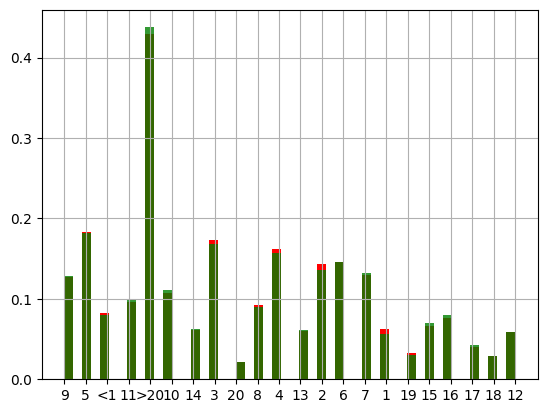

In [24]:
fig = plt.figure()
ax= fig.add_subplot(111)


#original data
df['experience'].hist(bins=50 , ax=ax, density =True, color ='red')


# data after cca

new_df['experience'].hist(bins =50, ax=ax , color ='green', density =True, alpha =0.8)

In [26]:
temp =pd.concat([
    df['enrolled_university'].value_counts() / len(df),

    new_df['enrolled_university'].value_counts() / len(new_df)

],
axis =1)


#add columns names

temp.columns = ["original","cca"]
temp


,original,cca
enrolled_university,,
no_enrollment,0.713481,0.727948
Full time course,0.204321,0.202180
Part time course,0.067637,0.069871


In [30]:
temp =pd.concat([
    df["education_level"].value_counts() / len(df),

    new_df["education_level"].value_counts() / len(new_df)

],
axis =1)


#add columns names

temp.columns = ["original","cca"]
temp


,original,cca
education_level,,
Graduate,0.596054,0.611497
Masters,0.232973,0.239346
High School,0.104274,0.106541
Phd,0.025364,0.026264
Primary School,0.016909,0.016353
